# Laboratorio 4: Costo, Eficiencia Computacional, Precisión Numérica y Condicionamiento de Problemas

En este laboratorio se trabajan los conceptos de costo y eficiencia computacional cubiertos en la Clase 3. Investigaremos cómo diferentes enfoques de implementación afectan el rendimiento de las operaciones de álgebra lineal, visualizaremos la complejidad de notación 'Big O' a través de experimentos de tiempo, y examinaremos el impacto de las elecciones de hardware y software en el rendimiento computacional. También, exploraremos los conceptos de precisión numérica y condicionamiento de problemas discutidos en la Clase. Investigaremos cómo las computadoras representan y manipulan números de punto flotante, las limitaciones de estas representaciones, y cómo estas limitaciones pueden afectar la precisión de nuestros cálculos. Por último, examinaremos el concepto de condicionamiento de problemas y cómo afecta la estabilidad de los algoritmos numéricos.

Al final de este laboratorio, serás capaz de:
1. Comprender el impacto práctico de la vectorización
2. Medir empíricamente y visualizar la complejidad de algoritmos
3. Evaluar la eficiencia de diferentes enfoques para resolver sistemas lineales

## Estructura del laboratorio
1. Vectorización
    - 1.0 Medición de tiempos de ejecución
    - 1.1 Bucles vs. operaciones vectorizadas
2. Visualización de la complejidad computacional de algoritmos
    - 2.1 Medición empírica de los tiempos de ejecución vs. tamaño de entrada
    - 2.2 Distintos métodos de resolución de sistemas lineales
3. Precisión Numérica y Punto Flotante
    1. Punto Flotante (IEEE 754)
    2. Epsilon de máquina
    3. Errores en la aritmética de punto flotante
4. Condicionamiento de Problemas

## 1. Costo y Eficiencia Computacional


### Vectorización

La vectorización y el broadcasting son funcionalidades nativas de NumPy que permiten acelerar el código al realizar operaciones de álgebra lineal. Las mismas permiten evitar el uso de bucles, y delegar la ejecución de operaciones a implementaciones ya optimizadas en C y Fortran. En esta sección se presentan ejemplos de cómo acelerar el código con NumPy.

### Medición de Tiempos

El módulo `timeit` ayuda a medir el tiempo de ejecución.  En la siguiente celda se presenta un ejemplo de cómo medir el tiempo de ejecución de una operación de inversión de matrices en función del tamaño de la matriz.

**Notas:** Si bien el módulo `timeit` es bastante preciso, a la hora de medir tiempos de ejecución, deben tenerse en cuenta las siguientes consideraciones:
- El tiempo de ejecución puede variar entre ejecuciones, según la carga de la máquina/entorno, y el perfil de uso de energía del dispositivo (power throttling, thermal throttling).  El primer problema puede mitigarse ejecutando varias veces el código y promediando los tiempos. El segundo problema puede mitigarse ejecutando el código en un entorno controlado.
- El tiempo de ejecución varía según el hardware subyacente, y las versiones de software utilizadas.
- Cuando el tiempo de ejecución es muy corto, la precisión de `timeit` puede no ser suficiente. Distintos ambientes de desarrollo ofrecen herramientas más precisas para medir tiempos de ejecución.

In [41]:
# Ejemplo: Medición del tiempo de inversión matricial
import numpy as np
import math
import timeit
import matplotlib.pyplot as plt
def tiempo_inversion(n):
    """Mide el tiempo de inversión de una matriz n×n."""
    # Crear una matriz aleatoria n×n
    A = np.random.rand(n, n)
    
    # Medir el tiempo de inversión
    N=100
    t = timeit.timeit(lambda: np.linalg.inv(A), number=N)
    
    return t / N  # Tiempo promedio por inversión

# Prueba para matriz de 1000x1000
tiempo = tiempo_inversion(1000) 
print(f"Tiempo de inversión de matriz 100x100: {tiempo:.2e} s")

Tiempo de inversión de matriz 100x100: 4.43e-02 s


### 1.1 Vectorización

La vectorización es el proceso de reemplazar bucles (`for`) con operaciones vectoriales, lo que puede mejorar significativamente el rendimiento.  Como regla general, se debe evitar el uso de bucles siempre que sea posible, y en su lugar utilizar operaciones vectoriales.  

Adicionalmente, las funciones nativas de NumPy están optimizadas para operar sobre arreglos de manera eficiente, y su uso puede acelerar significativamente el código.  En general, se recomienda utilizar funciones de NumPy en lugar de implementar operaciones manualmente.

En la siguiente celda se presentan ejemplos de lo anterior.

In [42]:
# Ejemplo: Cálculo de la distancia euclidiana entre puntos
def distancia_euclidiana_bucle(x, y):
    """Calcula la distancia euclidiana usando un bucle."""
    if len(x) != len(y):
        raise ValueError("Los vectores deben tener la misma longitud")
    
    suma_cuadrados = 0
    for i in range(len(x)):
        suma_cuadrados += (x[i] - y[i]) ** 2
    
    return np.sqrt(suma_cuadrados)

def distancia_euclidiana_vector(x, y):
    """Calcula la distancia euclidiana usando vectorización."""
    return np.sqrt(np.sum((x - y) ** 2))

def distancia_euclidiana_numpy(x, y):
    """Calcula la distancia euclidiana usando la función de NumPy."""
    return np.linalg.norm(x - y)

# Crear dos vectores aleatorios
n = 1000
x = np.random.rand(n)
y = np.random.rand(n)

# Medir tiempo de ambos enfoques
tiempo_bucle = timeit.timeit(lambda: distancia_euclidiana_bucle(x, y), number=1000)
tiempo_vector = timeit.timeit(lambda: distancia_euclidiana_vector(x, y), number=1000)
tiempo_norma = timeit.timeit(lambda: distancia_euclidiana_numpy(x, y), number=1000)

print(f"Enfoque basado en bucle: {tiempo_bucle:.6f} segundos")
print(f"Enfoque vectorizado: {tiempo_vector:.6f} segundos")
print(f"Factor de aceleración: {tiempo_bucle / tiempo_vector:.2f}x")
print(f"Enfoque basado en norma: {tiempo_norma:.6f} segundos")
print(f"Factor de aceleración: {tiempo_bucle / tiempo_norma:.2f}x")

Enfoque basado en bucle: 0.272488 segundos
Enfoque vectorizado: 0.014694 segundos
Factor de aceleración: 18.54x
Enfoque basado en norma: 0.003490 segundos
Factor de aceleración: 78.07x


**Ejercicio 1.1.1:** Implemente y compare versiones basadas en bucles y vectorizadas de:
1. Cálculo de la media de un vector grande
2. Encontrar el elemento máximo en cada fila de una matriz
3. Cálculo del producto elemento por elemento de dos vectores grandes

In [43]:
# --- 1. Media de un vector grande ---
def media_bucle(v):
    suma = 0
    for i in range(len(v)):
        suma += v[i]
    return suma / len(v)

def media_vectorizada(v):
    return np.sum(v) / len(v)

def media_numpy(v):
    return np.mean(v)

# --- 2. Maximo por fila de una matriz ---
def max_fila_bucle(M):
    filas = M.shape[0]
    resultado = np.empty(filas)
    for i in range(filas):
        maximo = M[i, 0]
        for j in range(1, M.shape[1]):
            if M[i, j] > maximo:
                maximo = M[i, j]
        resultado[i] = maximo
    return resultado

def max_fila_numpy(M):
    return np.max(M, axis=1)

# --- 3. Producto elemento por elemento ---
def producto_elem_bucle(a, b):
    resultado = np.empty(len(a))
    for i in range(len(a)):
        resultado[i] = a[i] * b[i]
    return resultado

def producto_elem_numpy(a, b):
    return a * b

# --- Comparacion de tiempos ---
n = 10000
v = np.random.rand(n)
M = np.random.rand(200, 200)
a = np.random.rand(n)
b = np.random.rand(n)
repeticiones = 100

print("=== 1. Media de un vector ===")
t_bucle = timeit.timeit(lambda: media_bucle(v), number=repeticiones)
t_vec = timeit.timeit(lambda: media_vectorizada(v), number=repeticiones)
t_np = timeit.timeit(lambda: media_numpy(v), number=repeticiones)
print(f"Bucle:        {t_bucle:.6f} s")
print(f"Vectorizada:  {t_vec:.6f} s  ({t_bucle / t_vec:.1f}x)")
print(f"np.mean:      {t_np:.6f} s  ({t_bucle / t_np:.1f}x)")

print("\n=== 2. Maximo por fila de una matriz ===")
t_bucle = timeit.timeit(lambda: max_fila_bucle(M), number=repeticiones)
t_np = timeit.timeit(lambda: max_fila_numpy(M), number=repeticiones)
print(f"Bucle:        {t_bucle:.6f} s")
print(f"np.max:       {t_np:.6f} s  ({t_bucle / t_np:.1f}x)")

print("\n=== 3. Producto elemento por elemento ===")
t_bucle = timeit.timeit(lambda: producto_elem_bucle(a, b), number=repeticiones)
t_np = timeit.timeit(lambda: producto_elem_numpy(a, b), number=repeticiones)
print(f"Bucle:        {t_bucle:.6f} s")
print(f"Vectorizado:  {t_np:.6f} s  ({t_bucle / t_np:.1f}x)")

=== 1. Media de un vector ===
Bucle:        0.108702 s
Vectorizada:  0.000564 s  (192.7x)
np.mean:      0.001727 s  (63.0x)

=== 2. Maximo por fila de una matriz ===
Bucle:        0.386104 s
np.max:       0.001277 s  (302.4x)

=== 3. Producto elemento por elemento ===
Bucle:        0.180232 s
Vectorizado:  0.000326 s  (552.2x)



**Ejercicio 1.1.2:** Escribe una función para calcular el producto escalar de dos vectores:
1. Implementa una versión basada en bucle
2. Usando `np.sum(v1 * v2)`
3. Usando `np.dot` o `@`
3. Compara su rendimiento para vectores de diferentes tamaños

In [45]:
def producto_escalar_bucle(v1, v2):
    suma = 0
    for i in range(len(v1)):
        suma += v1[i] * v2[i]
    return suma

def producto_escalar_sum(v1, v2):
    return np.sum(v1 * v2)

def producto_escalar_dot(v1, v2):
    return np.dot(v1, v2)

lengths = [100, 1000, 10000, 100000]
repeticiones = 100

for n in lengths:
    v1 = np.random.rand(n)
    v2 = np.random.rand(n)

    t_bucle = timeit.timeit(lambda: producto_escalar_bucle(v1, v2), number=repeticiones)
    t_sum = timeit.timeit(lambda: producto_escalar_sum(v1, v2), number=repeticiones)
    t_dot = timeit.timeit(lambda: producto_escalar_dot(v1, v2), number=repeticiones)

    print(f"n={n:>6} | bucle: {t_bucle:.4f}s | np.sum: {t_sum:.4f}s ({t_bucle/t_sum:.1f}x) | np.dot: {t_dot:.4f}s ({t_bucle/t_dot:.1f}x)")

n=   100 | bucle: 0.0022s | np.sum: 0.0004s (5.9x) | np.dot: 0.0001s (23.5x)
n=  1000 | bucle: 0.0259s | np.sum: 0.0005s (51.1x) | np.dot: 0.0001s (252.7x)
n= 10000 | bucle: 0.1938s | np.sum: 0.0015s (125.4x) | np.dot: 0.0002s (977.4x)
n=100000 | bucle: 1.7511s | np.sum: 0.0064s (273.5x) | np.dot: 0.0074s (236.1x)


## 2. Visualizando la Complejidad Computacional de Algoritmos

### 2.1 Medición Empírica de los Tiempos de Ejecución vs. Tamaño de Entrada

La notación Big O proporciona límites de complejidad teóricos, pero las mediciones empíricas pueden validar estos límites y revelar características de rendimiento prácticas.  La siguiente celda define algunas funciones auxiliares útiles para medir los tiempos de ejecución de algoritmos en función del tamaño de la entrada, junto con un ejemplo de cómo usarlas.

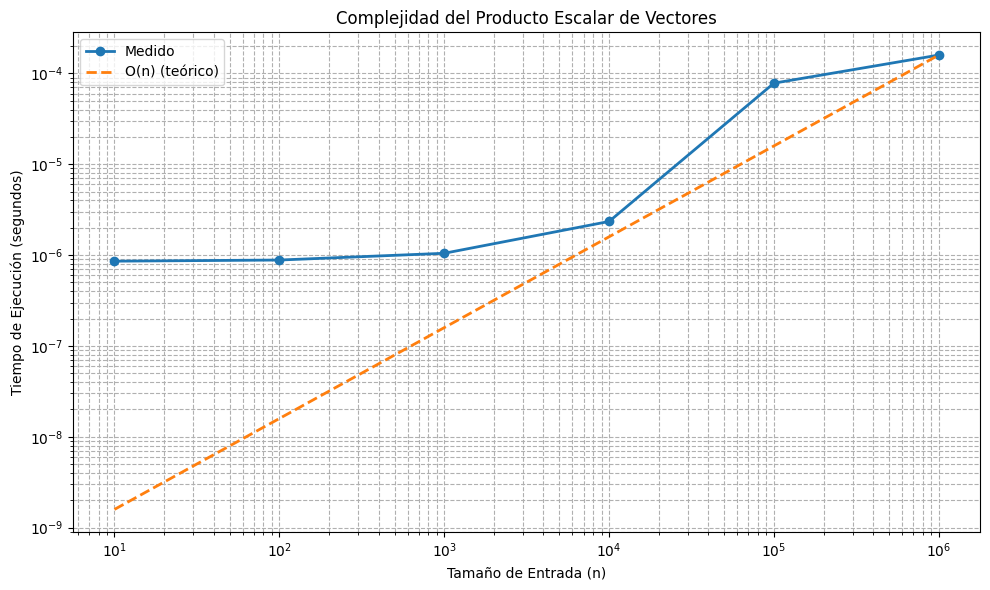

In [47]:
import timeit
import numpy as np
import matplotlib.pyplot as plt
def medir_tiempo_ejecucion(func, tamaños, *args, repeticiones=3, **kwargs):
    """Mide el tiempo de ejecución de una función para diferentes tamaños de entrada."""
    tiempos = []
    for tamaño in tamaños:
        tiempos_tamaño = []
        entradas = [arg(tamaño) if callable(arg) else arg for arg in args]           
        # Medir tiempo de ejecución
        tiempo = timeit.timeit(lambda: func(*entradas, **kwargs), number=repeticiones)
        tiempos.append(tiempo/repeticiones)
    
    return np.array(tiempos)

def graficar_complejidad(tamaños, tiempos, etiquetas, titulo, escala_log=True):
    """Grafica tiempos de ejecución y curvas de complejidad teóricas."""
    plt.figure(figsize=(10, 6))
    
    # Graficar tiempos medidos
    plt.plot(tamaños, tiempos, 'o-', linewidth=2, label='Medido')
    
    # Graficar curvas teóricas
    for etiqueta, curva in etiquetas.items():
        # Normalizar para coincidir con el último punto medido
        normalizada = curva * (tiempos[-1] / curva[-1])
        plt.plot(tamaños, normalizada, '--', linewidth=2, label=f'{etiqueta} (teórico)')
    
    plt.xlabel('Tamaño de Entrada (n)')
    plt.ylabel('Tiempo de Ejecución (segundos)')
    plt.title(titulo)
    
    if escala_log:
        plt.xscale('log')
        plt.yscale('log')
        plt.grid(True, which="both", ls="--")
    
    plt.legend()
    plt.tight_layout()
    plt.show()

# Ejemplo: Midiendo producto punto de vectores (esperado O(n))
tamaños = [10, 100, 1000, 10000, 100000, 1000000]

# Función para crear un vector aleatorio de tamaño dado
gen_vector = lambda n: np.random.rand(n)

# Medir tiempo de ejecución
tiempos = medir_tiempo_ejecucion(np.dot, tamaños, gen_vector, gen_vector, repeticiones=10000)

# Graficar resultados con curva teórica O(n)
graficar_complejidad(tamaños, tiempos, {'O(n)': np.array(tamaños)}, 'Complejidad del Producto Escalar de Vectores')

#### Ejercicios:

**Ejercicio 2.1.1:** Mide y visualiza la complejidad de las siguientes operaciones:
   - Suma de vectores (esperado O(n))
   - Multiplicación matriz-vector (esperado O(n²))
   - Multiplicación matriz-matriz (esperado O(n³) para implementación ingenua)
   - Cálculo del determinante de matriz (esperado O(n³))
   - Cálculo de la inversa de matriz (esperado O(n³))

Para cada operación, compara el tiempo medido con la curva de complejidad teórica. ¿Son consistentes? Si no, explica las discrepancias.



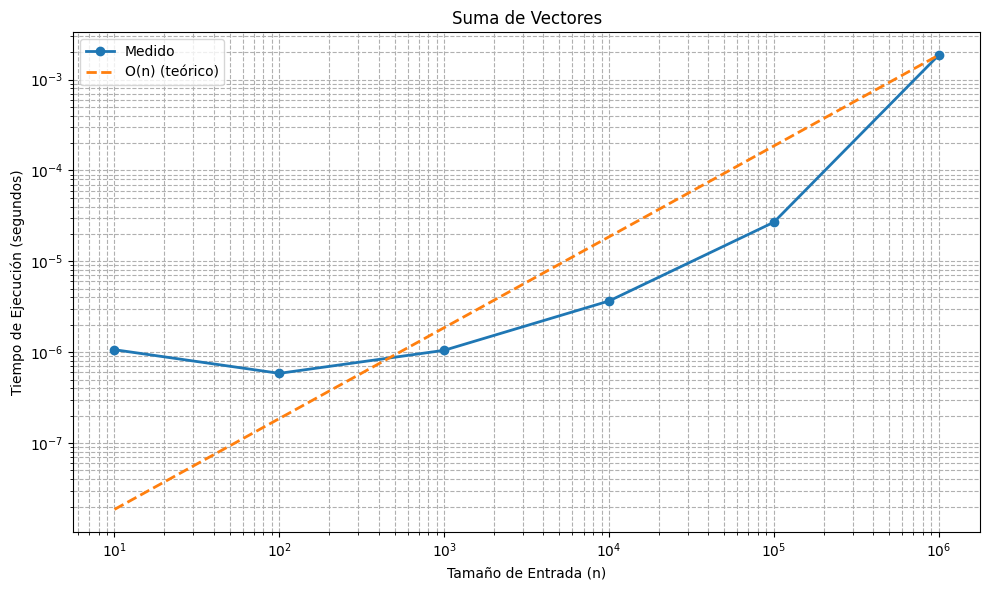

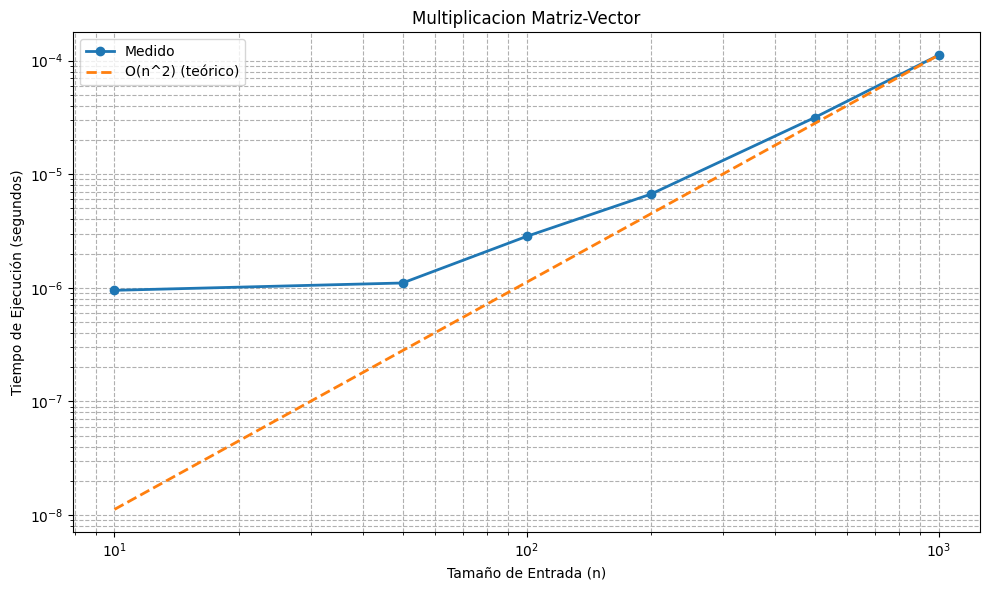

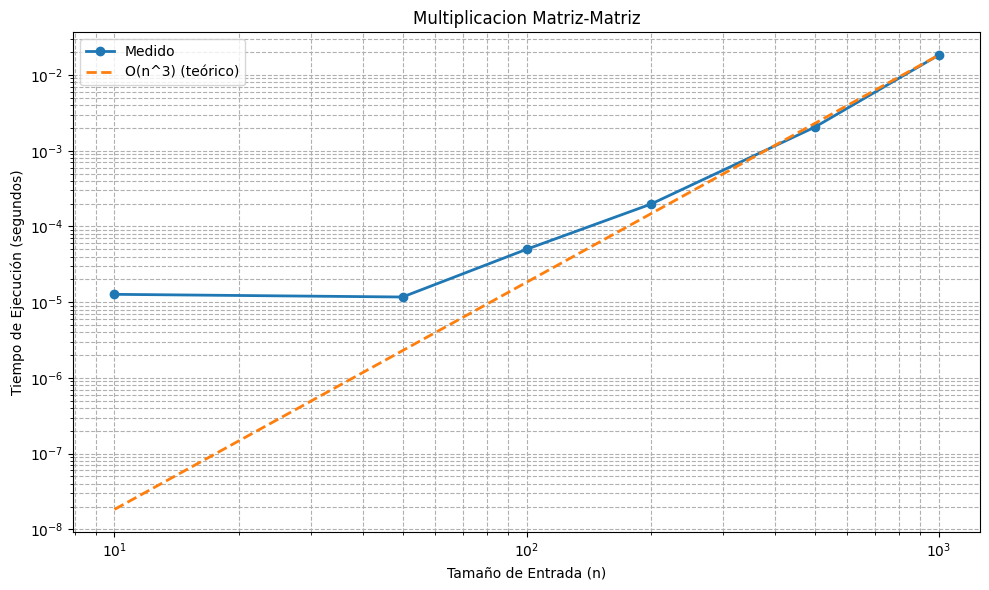

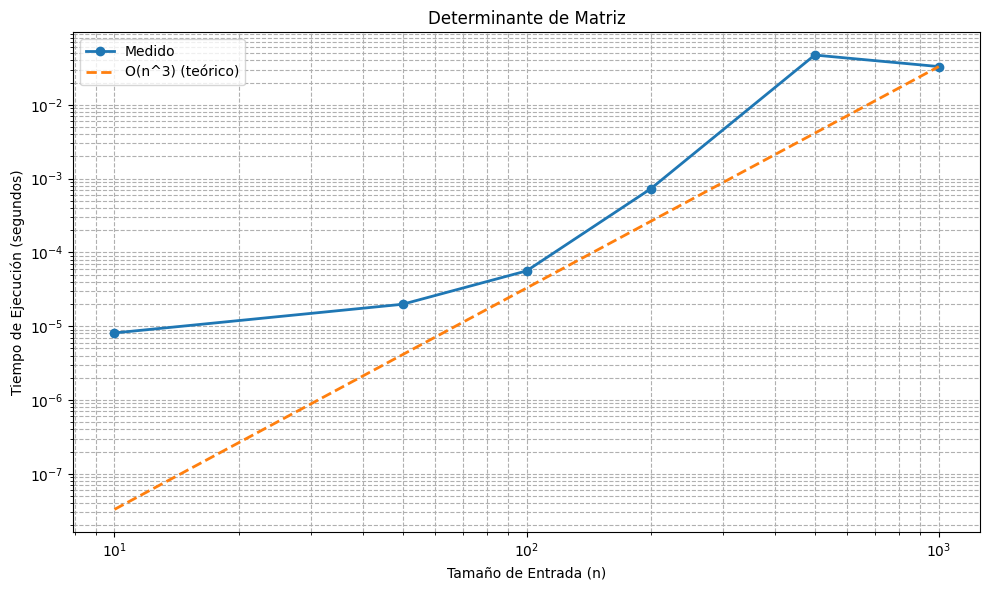

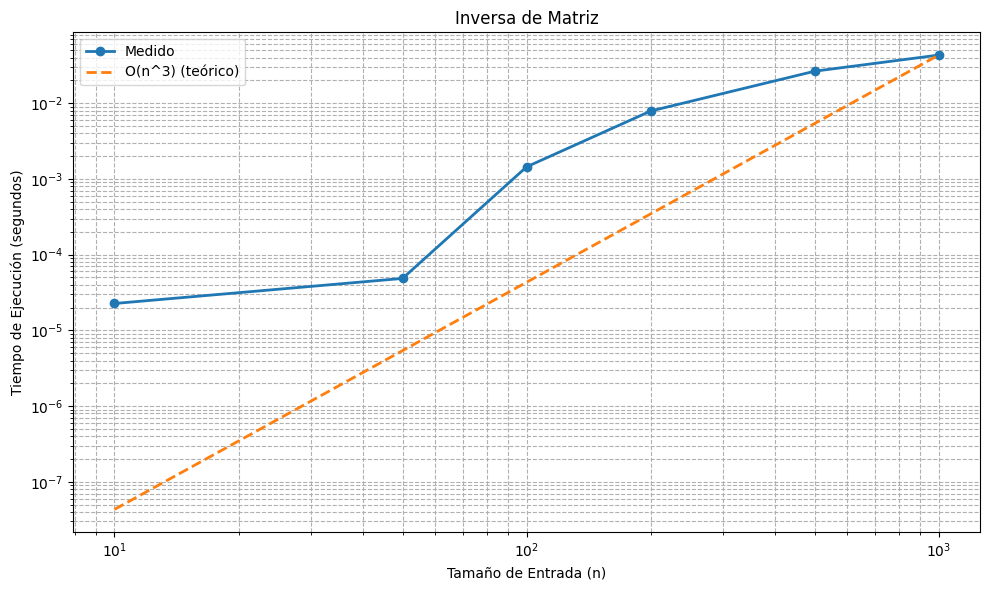

=== Analisis de consistencia ===
Suma vectores:   consistente con O(n). Para n chico el overhead de NumPy domina.
Mat-vector:      consistente con O(n^2). Pendiente log-log cercana a 2.
Mat-mat:         sigue O(n^3) pero puede escalar mejor por optimizaciones BLAS.
Determinante:    consistente con O(n^3), usa factorizacion LU internamente.
Inversa:         consistente con O(n^3), misma razon (LU + back-substitution).
Discrepancias:   en n chico, el overhead constante distorsiona la curva.
                 En n grande, limites de cache/memoria pueden aplanar tiempos.


In [49]:
gen_vector = lambda n: np.random.rand(n)
gen_matrix = lambda n: np.random.rand(n, n)

# 1. Suma de vectores - O(n)
tamanios_vec = [10, 100, 1000, 10000, 100000, 1000000]
tiempos_suma = medir_tiempo_ejecucion(np.add, tamanios_vec, gen_vector, gen_vector, repeticiones=1000)
graficar_complejidad(tamanios_vec, tiempos_suma, {'O(n)': np.array(tamanios_vec, dtype=float)}, 'Suma de Vectores')

# 2. Multiplicacion matriz-vector - O(n^2)
tamanios_mat = [10, 50, 100, 200, 500, 1000]
tiempos_matvec = medir_tiempo_ejecucion(np.dot, tamanios_mat, gen_matrix, gen_vector, repeticiones=100)
graficar_complejidad(tamanios_mat, tiempos_matvec, {'O(n^2)': np.array(tamanios_mat, dtype=float)**2}, 'Multiplicacion Matriz-Vector')

# 3. Multiplicacion matriz-matriz - O(n^3)
tiempos_matmat = medir_tiempo_ejecucion(np.dot, tamanios_mat, gen_matrix, gen_matrix, repeticiones=10)
graficar_complejidad(tamanios_mat, tiempos_matmat, {'O(n^3)': np.array(tamanios_mat, dtype=float)**3}, 'Multiplicacion Matriz-Matriz')

# 4. Determinante - O(n^3)
tiempos_det = medir_tiempo_ejecucion(np.linalg.det, tamanios_mat, gen_matrix, repeticiones=10)
graficar_complejidad(tamanios_mat, tiempos_det, {'O(n^3)': np.array(tamanios_mat, dtype=float)**3}, 'Determinante de Matriz')

# 5. Inversa - O(n^3)
tiempos_inv = medir_tiempo_ejecucion(np.linalg.inv, tamanios_mat, gen_matrix, repeticiones=10)
graficar_complejidad(tamanios_mat, tiempos_inv, {'O(n^3)': np.array(tamanios_mat, dtype=float)**3}, 'Inversa de Matriz')

print("=== Analisis de consistencia ===")
print("Suma vectores:   consistente con O(n). Para n chico el overhead de NumPy domina.")
print("Mat-vector:      consistente con O(n^2). Pendiente log-log cercana a 2.")
print("Mat-mat:         sigue O(n^3) pero puede escalar mejor por optimizaciones BLAS.")
print("Determinante:    consistente con O(n^3), usa factorizacion LU internamente.")
print("Inversa:         consistente con O(n^3), misma razon (LU + back-substitution).")
print("Discrepancias:   en n chico, el overhead constante distorsiona la curva.")
print("                 En n grande, limites de cache/memoria pueden aplanar tiempos.")

### 2.2 Resolviendo Sistemas Lineales: Eliminación Gaussiana vs. Inversión de Matrices

Comparemos diferentes enfoques para resolver sistemas lineales de la forma Ax = b y verifiquemos su complejidad teórica.  Se utilizarán las funciones `np.linalg.solve` y `np.linalg.inv` para resolver sistemas lineales y medir su rendimiento. 

A continuación se brinda una función auxiliar para generar problemas de sistemas lineales de tamaño n.  También se brindan funciones (**para completar**) para resolver sistemas lineales mediante eliminación gaussiana y mediante inversión de matrices.

In [52]:
def generar_sistema_aleatorio(n):
    """Genera un sistema lineal aleatorio no singular de tamaño n."""
    A = np.random.rand(n, n)
    A = A @ A.T + n * np.eye(n)
    b = np.random.rand(n)
    return A, b

def resolver_por_inversa(A, b):
    """Resuelve un sistema lineal usando inversión de matriz."""
    x = np.linalg.inv(A) @ b
    return x

def resolver_por_gaussiana(A, b):
    """Resuelve un sistema lineal usando eliminación gaussiana (vía numpy.linalg.solve)."""
    x = np.linalg.solve(A, b)
    return x

# Ejemplo de uso:
A, b = generar_sistema_aleatorio(3)
print("Matriz A:")
print(A)
print("\nVector b:")
print(b)
x_inv = resolver_por_inversa(A, b)
x_gauss = resolver_por_gaussiana(A, b)
print("\nSolución por inversa:")
print(x_inv)
print("\nSolución por eliminación gaussiana:")
print(x_gauss)
print("\nDiferencia entre soluciones:", np.linalg.norm(x_inv - x_gauss))
#Verificar que es una solución correcta
print("\nVerificación de la solución x:")
print("Ax-b:")
print(A @ x_gauss - b)
print("Norma de Ax-b:", np.linalg.norm(A @ x_gauss - b))

Matriz A:
[[4.26330121 1.1642599  0.76383787]
 [1.1642599  4.23745952 0.91309621]
 [0.76383787 0.91309621 4.4387114 ]]

Vector b:
[0.35861799 0.2140191  0.943016  ]

Solución por inversa:
[ 0.0493013  -0.00731509  0.20547341]

Solución por eliminación gaussiana:
[ 0.0493013  -0.00731509  0.20547341]

Diferencia entre soluciones: 1.179739509965479e-17

Verificación de la solución x:
Ax-b:
[0.00000000e+00 0.00000000e+00 1.11022302e-16]
Norma de Ax-b: 1.1102230246251565e-16


**Ejercicio 2.2.1:** Compara el rendimiento de diferentes enfoques para resolver sistemas lineales:
   - Usando inversión de matriz (A⁻¹b)
   - Usando eliminación gaussiana (solución directa)
   
Para ambos métodos, mide el tiempo de ejecución en función del tamaño de la matriz A y grafica utilizando las funciones introducidas anteriormente.  Verifica que las soluciones de ambos son efectivamente soluciones al sistema.


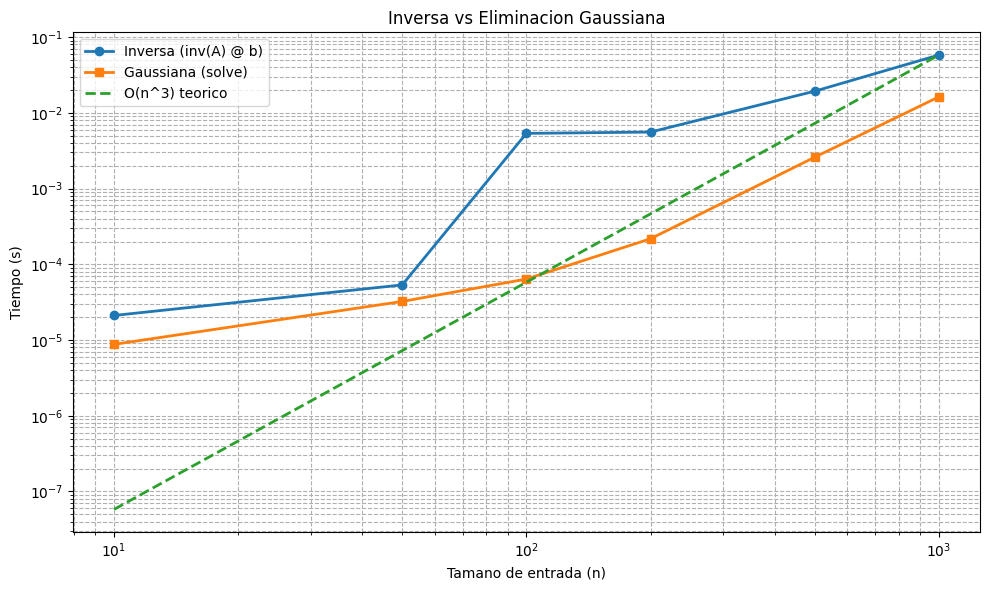


=== Verificacion de soluciones ===
n=10: ||Ax_inv - b|| = 3.55e-16, ||Ax_gauss - b|| = 2.22e-16, speedup inversa/gauss = 2.41x
n=100: ||Ax_inv - b|| = 2.82e-15, ||Ax_gauss - b|| = 2.42e-15, speedup inversa/gauss = 83.87x
n=500: ||Ax_inv - b|| = 3.01e-14, ||Ax_gauss - b|| = 1.91e-14, speedup inversa/gauss = 7.45x


In [53]:
tamanios = [10, 50, 100, 200, 500, 1000]
tiempos_inv = []
tiempos_gauss = []
repeticiones = 10

for n in tamanios:
    A, b = generar_sistema_aleatorio(n)
    t_inv = timeit.timeit(lambda: resolver_por_inversa(A, b), number=repeticiones) / repeticiones
    t_gauss = timeit.timeit(lambda: resolver_por_gaussiana(A, b), number=repeticiones) / repeticiones
    tiempos_inv.append(t_inv)
    tiempos_gauss.append(t_gauss)

plt.figure(figsize=(10, 6))
plt.plot(tamanios, tiempos_inv, 'o-', linewidth=2, label='Inversa (inv(A) @ b)')
plt.plot(tamanios, tiempos_gauss, 's-', linewidth=2, label='Gaussiana (solve)')
teorico = np.array(tamanios, dtype=float)**3
teorico_norm = teorico * (tiempos_inv[-1] / teorico[-1])
plt.plot(tamanios, teorico_norm, '--', linewidth=2, label='O(n^3) teorico')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tamano de entrada (n)')
plt.ylabel('Tiempo (s)')
plt.title('Inversa vs Eliminacion Gaussiana')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

print("\n=== Verificacion de soluciones ===")
for n in [10, 100, 500]:
    A, b = generar_sistema_aleatorio(n)
    x_inv = resolver_por_inversa(A, b)
    x_gauss = resolver_por_gaussiana(A, b)
    print(f"n={n}: ||Ax_inv - b|| = {np.linalg.norm(A @ x_inv - b):.2e}, "
          f"||Ax_gauss - b|| = {np.linalg.norm(A @ x_gauss - b):.2e}, "
          f"speedup inversa/gauss = {tiempos_inv[tamanios.index(n) if n in tamanios else 0] / tiempos_gauss[tamanios.index(n) if n in tamanios else 0]:.2f}x")

## 3. Precisión Numérica y Punto Flotante
### 3.1 Punto Flotante (IEEE 754)

**Ejercicio 3.1.1** Defina en numpy una variable `x=0.1` e imprimala utilizando `print(f"{x:.20f}")` ¿Qué valor tiene `x`? ¿Es exactamente 0.1? ¿Por qué?

*NOTA:* La notación `f"{x:.20f}"` imprime el valor de `x` con 20 decimales.

La clase `float` de Python utiliza por defecto precisión doble (64 bits).  `numpy` permite seleccionar la precisión de los números flotantes. Por ejemplo, `np.float32` crea un número flotante de precisión simple (32 bits).

In [18]:
x = 0.1
print(f"{x:.20f}")


0.10000000000000000555



**Ejercicio 3.1.2** Defina en numpy una variable `x=0.1` como un número flotante de doble precisión e imprimala utilizando `print(f"{x:.20f}")` ¿Qué valor tiene `x`? 

In [19]:
np.float64(x)
print(f"{x:.20f}")

0.10000000000000000555



**Ejercicio 3.1.3** Defina en numpy una variable `x=0.1` como un número flotante de precisión simple e imprimala utilizando `print(f"{x:.20f}")` ¿Qué valor tiene `x`? 

In [21]:
np.float32(x)
print(f"{x:.20f}")

0.10000000149011611938


**Ejercicio 3.1.4** Defina en numpy una variable `x=0.1` como un número flotante de media precisión e imprimala utilizando `print(f"{x:.20f}")` ¿Qué valor tiene `x`? 

*NOTA:* La precisión de los números flotantes en `numpy` se puede seleccionar utilizando `np.float16`, `np.float32`, `np.float64`.

In [22]:
np.float16(x)
print(f"{x:.20f}")

0.10000000149011611938


**Ejericio 3.1.5** La función `np.fininfo` de `numpy` permite obtener información sobre los números flotantes. Utilice esta función para obtener información sobre los números flotantes de precisión simple, doble y media. ¿Cuál es la precisión de cada uno de estos tipos de números flotantes?

In [25]:
fininfo_16 = np.finfo(np.float16)
print("Información de np.float16:")
print(f"Precisión: {fininfo_16.precision} dígitos decimales")
print(f"Máximo valor representable: {fininfo_16.max}")     

print("-" * 50 )

fininfo_32 = np.finfo(np.float32)
print("Información de np.float32:")
print(f"Precisión: {fininfo_32.precision} dígitos decimales")
print(f"Máximo valor representable: {fininfo_32.max}")     

print("-" * 50 )

fininfo_64 = np.finfo(np.float64)
print("Información de np.float64:")
print(f"Precisión: {fininfo_64.precision} dígitos decimales")
print(f"Máximo valor representable: {fininfo_64.max}")     

Información de np.float16:
Precisión: 3 dígitos decimales
Máximo valor representable: 65504.0
--------------------------------------------------
Información de np.float32:
Precisión: 6 dígitos decimales
Máximo valor representable: 3.4028234663852886e+38
--------------------------------------------------
Información de np.float64:
Precisión: 15 dígitos decimales
Máximo valor representable: 1.7976931348623157e+308


### 3.2 Precisión relativa y epsilon de máquina
La función `math.nextafter()` de Python devuelve el siguiente número de punto flotante más cercano a un número dado en la dirección especificada. Por ejemplo, `math.nextafter(1.0, math.inf)` devuelve el siguiente número de punto flotante más grande después de 1.0. 

**Ejercicio 3.2.1** Utilice la función `math.nextafter()` para calcular la distancia entre los siguientes números: `0.001, 1.0, 1000.` y el siguiente número de punto flotante más grande. Imprima la distancia absoluta y relativa entre dichos números y el siguiente en la representación de punto flotante. ¿Qué puede concluir sobre la precisión de los números de punto flotante?

In [27]:
numeros = [0.001, 1.0, 1000.0]

for x in numeros:
    next = math.nextafter(x, math.inf)
    dist_abs = abs(next - x)
    dist_rel = dist_abs / abs(x) if x != 0 else float('inf')
    print(f"  Distancia absoluta: {dist_abs:.6e}")
    print(f"  Distancia relativa: {dist_rel:.6e}")
    print()

  Distancia absoluta: 2.168404e-19
  Distancia relativa: 2.168404e-16

  Distancia absoluta: 2.220446e-16
  Distancia relativa: 2.220446e-16

  Distancia absoluta: 1.136868e-13
  Distancia relativa: 1.136868e-16




**Ejercicio 3.2.2** Busque el valor de `epsilon` en Python y comparelo con el valor de las precisiones relativas calculadas en el Ejercicio 3.2.1. 

In [54]:
eps = np.finfo(np.float64).eps
print(f"Epsilon de maquina (float64): {eps:.6e}")

Epsilon de maquina (float64): 2.220446e-16


### 3.3 Errores en la aritmética de punto flotante
La aritmética de punto flotante es aproximada.  En general, es posible esperar que las operaciones en punto flotante respeten el "axioma":
$$ x \oplus y = (x + y)(1 + \epsilon), \, \epsilon \leq \epsilon_{\text{maq}}$$
donde $\oplus$ es una operación cualquiera de punto flotante entre dos elementos $x$ e $y$, $+$ es la operación en aritmética (real) estándar y $\epsilon$ es el error relativo de la operación.

**Ejercicio 3.3.1: Precisión aritmética** Considere los números $x=0.1$ e $y=0.2$. Calcule su suma $z=x+y$ en punto flotante y evalúe la expresión booleana `z==0.3`. ¿Qué sucede? Calcule el error relativo respecto del valor esperado y comparelo con el valor de $\epsilon_{\text{maq}}$. ¿El error relativo de la suma es menor o mayor que $\epsilon_{\text{maq}}$?

In [31]:
x = 0.1
y = 0.2

z = x + y

print(f"{np.finfo(z)}")

Machine parameters for float64
---------------------------------------------------------------
precision =  15   resolution = 1.0000000000000001e-15
machep =    -52   eps =        2.2204460492503131e-16
negep =     -53   epsneg =     1.1102230246251565e-16
minexp =  -1022   tiny =       2.2250738585072014e-308
maxexp =   1024   max =        1.7976931348623157e+308
nexp =       11   min =        -max
smallest_normal = 2.2250738585072014e-308   smallest_subnormal = 4.9406564584124654e-324
---------------------------------------------------------------




**Ejercicio 3.3.2: Operaciones irrelevantes** Considere los números $x=1e16$ e $y=1$. Calcule su suma $z=x+y$ en punto flotante y evalúe la expresión booleana `z==x`. ¿Qué sucede/ Calcule el error relativo respecto del valor esperado y comparelo con el valor de $\epsilon_{\text{maq}}$. ¿El error relativo de la resta es menor o mayor que $\epsilon_{\text{maq}}$?

In [35]:
x = 1e16
y = 1

z = x + y

# La suma da igual a x?
print(f"z == x: {z == x}")

valor_esperado = 1e16 + 1  # = 10000000000000001
print(f" se esperaba {valor_esperado}")

# Error relativo
error_rel = abs(z - valor_esperado) / abs(valor_esperado)
eps = np.finfo(np.float64).eps

print(f"Error relativo: {error_rel:.6e}")
print(f"Epsilon maquina: {eps:.6e}")
print(f"Error < epsilon: {error_rel <= eps}")

z == x: True
 se esperaba 1e+16
Error relativo: 0.000000e+00
Epsilon maquina: 2.220446e-16
Error < epsilon: True


**Ejercicio 3.3.3: Cancelación catastrófica** Considere los números $x=0.123456789012345678$ y $y=0.123456789012345677$. Calcule su resta $z=x-y$ en punto flotante y evalúe la expresión booleana `z==0`. ¿Qué sucede? Calcule el error relativo respecto del valor esperado y comparelo con el valor de $\epsilon_{\text{maq}}$. ¿El error relativo de la resta es menor o mayor que $\epsilon_{\text{maq}}$?

In [39]:
y=0.123456789012345677
x=0.123456789012345678

z = x - y

print(f"x: {x:.20f}")
print(f"y: {y:.20f}")
print(f"z = x - y: {z:.20e}")
print(f"z == 0: {z == 0}")
print(f"x == y: {x == y}")

valor_esperado = 1e-18  # = 0.000000000000000001

# El error relativo no se puede calcular porque z = 0
# Esto demuestra cancelacion catastrofica total:
# la diferencia real es 1e-18, pero float64 no puede distinguir
# x de y porque difieren en un digito mas alla de la precision
# de la mantisa (52 bits ~ 15-16 digitos decimales)
eps = np.finfo(np.float64).eps
print(f"\nEpsilon maquina: {eps:.6e}")
print(f"Valor esperado: {valor_esperado:.6e}")
print(f"Error relativo: infinito (z=0, se perdio toda la informacion)")

x: 0.12345678901234567737
y: 0.12345678901234567737
z = x - y: 0.00000000000000000000e+00
z == 0: True
x == y: True

Epsilon maquina: 2.220446e-16
Valor esperado: 1.000000e-18
Error relativo: infinito (z=0, se perdio toda la informacion)



**Ejercicio 3.3.4: overflow** Estime (a mano o programáticamente) el orden de magnitud de $e^{800}$ y luego calcúlelo en python directamente. *Sugerencia:* note que $e^x = 10^{800\log_{10}(e)}$ . Repita el ejercicio anterior para $e^{-800}$ (underflow)

In [55]:
## --- Overflow: e^800 ---
exponente = 800 * math.log10(math.e)
print(f"e^800 = 10^(800 * log10(e)) = 10^{exponente:.2f}")
print(f"Orden de magnitud: ~10^{int(exponente)}")

try:
    resultado = np.exp(800)
    print(f"np.exp(800) = {resultado}")
except:
    print("np.exp(800) fallo")

print(f"np.exp(800) = {np.exp(800)}")
print(f"float64 max = {np.finfo(np.float64).max:.2e}")
print("Resultado: inf (overflow), porque 10^347 supera el maximo representable (~1.80e+308)")

print("\n--- Underflow: e^(-800) ---")
exponente_neg = -800 * math.log10(math.e)
print(f"e^(-800) = 10^(-800 * log10(e)) = 10^{exponente_neg:.2f}")
print(f"Orden de magnitud: ~10^{int(exponente_neg)}")

resultado_neg = np.exp(-800)
print(f"np.exp(-800) = {resultado_neg}")
print(f"float64 min subnormal = {np.finfo(np.float64).tiny:.2e}")
print("Resultado: 0.0 (underflow), porque 10^(-348) es menor que el minimo representable (~2.22e-308)")

e^800 = 10^(800 * log10(e)) = 10^347.44
Orden de magnitud: ~10^347
np.exp(800) = inf
np.exp(800) = inf
float64 max = 1.80e+308
Resultado: inf (overflow), porque 10^347 supera el maximo representable (~1.80e+308)

--- Underflow: e^(-800) ---
e^(-800) = 10^(-800 * log10(e)) = 10^-347.44
Orden de magnitud: ~10^-347
np.exp(-800) = 0.0
float64 min subnormal = 2.23e-308
Resultado: 0.0 (underflow), porque 10^(-348) es menor que el minimo representable (~2.22e-308)


C:\Users\arias\AppData\Local\Temp\ipykernel_17908\4218682631.py:7: RuntimeWarning: overflow encountered in exp
  resultado = np.exp(800)
C:\Users\arias\AppData\Local\Temp\ipykernel_17908\4218682631.py:12: RuntimeWarning: overflow encountered in exp
  print(f"np.exp(800) = {np.exp(800)}")


## 4. Condicionamiento de Problemas
### 4.1 Condicionamiento de un problema
El condicionamiento de un problema es una medida de cuánto cambia la solución de un problema cuando se cambian los datos de entrada. Un problema mal condicionado es aquel en el que pequeñas variaciones en los datos de entrada pueden resultar en grandes variaciones en la solución.  Un ejemplo clásico de un problema mal condicionado es el siguiente sistema lineal: 

$$\begin{bmatrix} 1 & 2 \\ 2 & 4.0001 \end{bmatrix} x = b$$

Con cualquier valor de $b$. 

**Ejercicio 4.1.1:** Sea $b_1=\begin{bmatrix} 3 \\ 6.0001 \end{bmatrix}$, halle la solución del sistema a mano.  Repita para $b_2=\begin{bmatrix} 3 \\ 6.0002 \end{bmatrix}$.   Calcule la variación relativa de la solución sobre la variación relativa del vector b:
$$ \frac{\|x_2-x_1\|}{\|x_1\|} / \frac{\|b_2-b_1\|}{\|b_1\|}$$

In [56]:
A = np.array([[1, 2], [2, 4.0001]])
b1 = np.array([3, 6.0001])
b2 = np.array([3, 6.0002])

x1 = np.linalg.solve(A, b1)
x2 = np.linalg.solve(A, b2)

var_x = np.linalg.norm(x2 - x1) / np.linalg.norm(x1)
var_b = np.linalg.norm(b2 - b1) / np.linalg.norm(b1)
cociente = var_x / var_b

kappa = np.linalg.cond(A)

print(f"x1 = {x1}")
print(f"x2 = {x2}")
print(f"Cociente variaciones: {cociente:.2e}")
print(f"Numero de condicion:  {kappa:.2e}")
print(f"Cociente <= kappa: {cociente <= kappa}")

x1 = [1. 1.]
x2 = [-1.  2.]
Cociente variaciones: 1.06e+05
Numero de condicion:  2.50e+05
Cociente <= kappa: True


**Ejercicio 4.1.2:** Calcule el número de condición de la matriz $A$.  Muestre que el cociente del problema anterior es menor este número de condición. 

In [59]:
A = np.array([[1, 2], [2, 4.0001]])
b1 = np.array([3, 6.0001])
b2 = np.array([3, 6.0002])

x1 = np.linalg.solve(A, b1)
x2 = np.linalg.solve(A, b2)

kappa = np.linalg.cond(A)
cociente = (np.linalg.norm(x2 - x1) / np.linalg.norm(x1)) / (np.linalg.norm(b2 - b1) / np.linalg.norm(b1))

print(f"Numero de condicion kappa(A) = {kappa:.2e}")
print(f"Cociente de variaciones      = {cociente:.2e}")
print(f"Cociente <= kappa(A): {cociente <= kappa}")
print(f"\nSe cumple la desigualdad: el cociente ({cociente:.2e}) es menor que kappa ({kappa:.2e})")
print("Esto es consistente con la cota teorica: ||dx||/||x|| / ||db||/||b|| <= kappa(A)")

Numero de condicion kappa(A) = 2.50e+05
Cociente de variaciones      = 1.06e+05
Cociente <= kappa(A): True

Se cumple la desigualdad: el cociente (1.06e+05) es menor que kappa (2.50e+05)
Esto es consistente con la cota teorica: ||dx||/||x|| / ||db||/||b|| <= kappa(A)


### 4.2 Propagación de errores y estabilidad algorítmica.
Los errores numéricos se propagan a través de los cálculos. Supongamos que queremos calcular:
$$
f(x) = \sqrt{x+1}-\sqrt{x}
$$ 
En el caso de que $x$ es muy grande, la resta de dos números casi iguales puede llevar a errores grandes (cancelación catastrófica).  Sin embargo, si reescribimos la función como:
$$f(x) = \frac{(\sqrt{x+1}-\sqrt{x})(\sqrt{x+1}+\sqrt{x})}{\sqrt{x+1}+\sqrt{x}} = \frac{x+1-x}{\sqrt{x+1}+\sqrt{x}} = \frac{1}{\sqrt{x+1}+\sqrt{x}}$$
podemos evitar la cancelación catastrófica.

Es decir: distintas estrategias de cálculo (algoritmos) pueden llevar a resultados con distintos niveles de precisión.

**Ejercicio 4.2.1:** Implemente las dos formas de calcular $f(x)$ en python.  Evalúe los resultados para $x=10$, $x=10^12$ y $x=10^{16}$. ¿Qué puede concluir sobre la estabilidad de los algoritmos?

**Ejercicio 4.2.2:** Considere el problema de hallar los valores propios de una matrix $A$ dada por:
$$A = \begin{pmatrix} 1+\epsilon & 0 \\ 0 & 1 \end{pmatrix}$$
donde $\epsilon$ es un número muy pequeño. Halle los valores propios de $A$ mediante cálculo directo (*Nota:* la matriz A es diagonal). Implemente un algoritmo para calcular los valores propios de $A$ mediante el cálculo y resolución del polinomio característico. Utilice su función para evaluar el caso en que $\epsilon=10^{-14}$.  Compare los resultados de este método con el cálculo directo realizado previamente. ¿Qué puede concluir sobre la precisión y estabilidad del algoritmo utilizados?

**Ejercicio 4.2.3:** Determine el número de condición de la matriz anterior.  ¿Es esperada la pérdida de precisión observada en el cálculo de los valores propios?

**Ejercicio 4.2.4:** Repita el ejercicio 4.2.2 utilizando ahora  `np.linalg.eigvals()` en lugar de calcular las raícies del polinomio característico. ¿Qué puede concluir sobre la precisión y estabilidad del algoritmo utilizado?

In [58]:
# === 4.2.1: Cancelacion catastrofica en f(x) = sqrt(x+1) - sqrt(x) ===
def f_inestable(x):
    return np.sqrt(x + 1) - np.sqrt(x)

def f_estable(x):
    return 1.0 / (np.sqrt(x + 1) + np.sqrt(x))

print("=== Ejercicio 4.2.1 ===")
for x in [10, 1e12, 1e16]:
    r_inestable = f_inestable(x)
    r_estable = f_estable(x)
    error_rel = abs(r_inestable - r_estable) / abs(r_estable) if r_estable != 0 else float('inf')
    print(f"x={x:.0e}: inestable={r_inestable:.15e}, estable={r_estable:.15e}, error_rel={error_rel:.2e}")

print("Para x grande, la resta de numeros casi iguales pierde digitos significativos.")
print("La version estable evita la resta y mantiene toda la precision.")

# === 4.2.2: Valores propios via polinomio caracteristico ===
print("\n=== Ejercicio 4.2.2 ===")
epsilon = 1e-14

A = np.array([[1 + epsilon, 0], [0, 1]])

lambda_directo = [1 + epsilon, 1]
print(f"Valores propios directos (lectura diagonal): {lambda_directo}")

# Polinomio caracteristico: det(A - lambda*I) = 0
# (1+eps - lambda)(1 - lambda) = 0
# lambda^2 - (2+eps)*lambda + (1+eps) = 0
a_coef = 1
b_coef = -(2 + epsilon)
c_coef = 1 + epsilon

discriminante = b_coef**2 - 4 * a_coef * c_coef
lambda1_poly = (-b_coef + np.sqrt(discriminante)) / (2 * a_coef)
lambda2_poly = (-b_coef - np.sqrt(discriminante)) / (2 * a_coef)

print(f"Valores propios via polinomio caracteristico: [{lambda1_poly}, {lambda2_poly}]")
print(f"Error en lambda1: {abs(lambda1_poly - (1 + epsilon)):.2e}")
print(f"Error en lambda2: {abs(lambda2_poly - 1):.2e}")
print("El discriminante es ~eps^2 (~1e-28), muy cercano a 0.")
print("Al calcular sqrt(discriminante), se pierde precision por cancelacion catastrofica.")

# === 4.2.3: Numero de condicion ===
print("\n=== Ejercicio 4.2.3 ===")
kappa = np.linalg.cond(A)
print(f"Numero de condicion kappa(A) = {kappa:.6f}")
print(f"kappa es cercano a 1, la matriz esta bien condicionada.")
print("La perdida de precision NO se debe al condicionamiento de la matriz,")
print("sino a la inestabilidad del algoritmo (resolver cuadratica con discriminante ~0).")

# === 4.2.4: Valores propios con np.linalg.eigvals ===
print("\n=== Ejercicio 4.2.4 ===")
eigvals = np.linalg.eigvals(A)
eigvals_sorted = np.sort(eigvals)[::-1]
print(f"Valores propios con eigvals: {eigvals_sorted}")
print(f"Error en lambda1: {abs(eigvals_sorted[0] - (1 + epsilon)):.2e}")
print(f"Error en lambda2: {abs(eigvals_sorted[1] - 1):.2e}")
print("np.linalg.eigvals usa algoritmos numericamente estables (QR/Schur),")
print("que no dependen de calcular raices de polinomios, evitando la cancelacion.")

=== Ejercicio 4.2.1 ===
x=1e+01: inestable=1.543471301870203e-01, estable=1.543471301870205e-01, error_rel=1.44e-15
x=1e+12: inestable=5.000038072466850e-07, estable=4.999999999998749e-07, error_rel=7.61e-06
x=1e+16: inestable=0.000000000000000e+00, estable=5.000000000000000e-09, error_rel=1.00e+00
Para x grande, la resta de numeros casi iguales pierde digitos significativos.
La version estable evita la resta y mantiene toda la precision.

=== Ejercicio 4.2.2 ===
Valores propios directos (lectura diagonal): [1.00000000000001, 1]
Valores propios via polinomio caracteristico: [1.0000000149011663, 0.9999999850988439]
Error en lambda1: 1.49e-08
Error en lambda2: 1.49e-08
El discriminante es ~eps^2 (~1e-28), muy cercano a 0.
Al calcular sqrt(discriminante), se pierde precision por cancelacion catastrofica.

=== Ejercicio 4.2.3 ===
Numero de condicion kappa(A) = 1.000000
kappa es cercano a 1, la matriz esta bien condicionada.
La perdida de precision NO se debe al condicionamiento de la matri